In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Data/netflix1.csv')

df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
print("Shape:",df.shape)

Shape: (8790, 10)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Dataset Summary

1. Dataset contains Netflix Movies and TV Shows.
2. It includes information about title, director, cast, country, release year and rating.
3. Missing values exist in several columns.
4. Movies and TV Shows are both represented.
5. Dataset can be used to analyze Netflix content trends globally.

 Step 2 - Clean the Data


In [ ]:

# Make a working copy
data = df.copy()

# 1. Fill missing categorical text fields with 'Unknown' / 'Not Specified'
#    Reason: director/country are descriptive attributes; dropping rows would lose
#    ~30% of data (director). Filling preserves rows for analyses that don't depend on these fields.
data['director'] = data['director'].fillna('Unknown')
data['country'] = data['country'].fillna('Unknown')

# 2. Drop the few rows missing 'date_added' or 'rating' (only 10 and 7 rows respectively)
#    Reason: too few rows to meaningfully impute, and these fields are needed for
#    time-trend and rating analysis, so dropping is safe and low-impact.
data = data.dropna(subset=['date_added', 'rating'])

# 3. Convert 'date_added' to datetime and extract year/month
#    Reason: enables trend analysis of content additions over time.
data['date_added'] = pd.to_datetime(data['date_added'].str.strip(), format='%m/%d/%Y')
data['year_added'] = data['date_added'].dt.year
data['month_added'] = data['date_added'].dt.month_name()

# 4. Split 'duration' into a numeric value and a unit
#    Reason: 'duration' mixes "90 min" (Movies) and "2 Seasons" (TV Shows) — must separate
#    to do numeric analysis (e.g., average movie length).
data['duration_value'] = data['duration'].str.extract(r'(\d+)').astype(float)
data['duration_unit'] = data['duration'].apply(lambda x: 'Season' if 'Season' in x else 'min')

# 5. Take the primary (first-listed) genre and country for simpler grouping
#    Reason: 'listed_in' and 'country' contain comma-separated multi-values;
#    using the first value gives a clean single category for groupby-based EDA
#    without discarding the full lists (kept in original columns).
data['primary_genre'] = data['listed_in'].apply(lambda x: x.split(',')[0].strip())
data['primary_country'] = data['country'].apply(lambda x: x.split(',')[0].strip())

# 6. (Removed section regarding 'description' as it does not exist)

print("Cleaned shape:", data.shape)
print("Remaining missing values:\n", data.isnull().sum())
data.head()

Cleaned shape: (8790, 16)
Remaining missing values:
 show_id            0
type               0
title              0
director           0
country            0
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
year_added         0
month_added        0
duration_value     0
duration_unit      0
primary_genre      0
primary_country    0
dtype: int64


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,month_added,duration_value,duration_unit,primary_genre,primary_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,September,90.0,min,Documentaries,United States
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,September,1.0,Season,Crime TV Shows,France
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,September,1.0,Season,TV Dramas,United States
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,September,91.0,min,Children & Family Movies,Brazil
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,September,125.0,min,Dramas,United States


# Data Cleaning Decisions

### 1. Handling Missing Values in `director` and `country`

Missing values in the `director` and `country` columns were replaced with **"Unknown"**. These columns are descriptive attributes, and dropping records with missing values would have resulted in a significant loss of data. Filling them with a placeholder value preserved the dataset while clearly indicating unavailable information.

### 2. Removing Rows with Missing `date_added` and `rating`

Rows containing missing values in the `date_added` and `rating` columns were removed. The number of missing records in these columns was very small compared to the overall dataset, so removing them had minimal impact on the analysis. These fields are important for time-based and content-rating analysis.

### 3. Converting `date_added` to Datetime Format

The `date_added` column was converted from a string format to a datetime format. This transformation enables efficient date-based analysis, such as identifying trends in content additions over time.

### 4. Creating `year_added` and `month_added`

Two new columns, `year_added` and `month_added`, were extracted from the `date_added` column. These features simplify the analysis of yearly and monthly content addition trends.

### 5. Separating Duration into Numeric and Categorical Components

The `duration` column contained mixed information such as "90 min" and "2 Seasons". To facilitate numerical analysis, the column was split into:

* `duration_value` (numeric part)
* `duration_unit` (minutes or seasons)

This allows calculations such as average movie length and average number of seasons for TV shows.

### 6. Extracting Primary Genre

The `listed_in` column contains multiple genres separated by commas. For easier grouping and visualization, the first listed genre was extracted into a new column called `primary_genre`.

### 7. Extracting Primary Country

The `country` column may contain multiple countries. The first country listed was extracted into a new column called `primary_country` to support simpler country-wise analysis.

### 8. Column Removal Decision

No columns were removed because all available columns were considered useful for Exploratory Data Analysis (EDA) and could contribute meaningful insights.

### Result

After cleaning and preprocessing, the dataset contained **8,790 records and 16 columns**, with **no remaining missing values**.


Step 3 - Exploratory Data Analysis


Q1: What is the split between Movies and TV Shows?


In [ ]:

type_counts = data['type'].value_counts()
print(type_counts)
print("\nPercentage:\n", (type_counts / len(data) * 100).round(2))


type
Movie      6126
TV Show    2664
Name: count, dtype: int64

Percentage:
 type
Movie      69.69
TV Show    30.31
Name: count, dtype: float64


Conclusion

Netflix content is dominated by Movies, which account for nearly 70% of the catalog.

Q2:Which countries produce the most on netflix?


In [ ]:
top_countries = data['primary_country'].value_counts().head(10)
top_countries

,count
primary_country,
United States,3240
India,1057
United Kingdom,638
Pakistan,421
Not Given,287
Canada,271
Japan,259
South Korea,214
France,213


Conclusion

The United States contributes the highest number of Netflix titles, followed by India and the United Kingdom.

Q3:How has the number of titles added to Netflix changed over the years?

In [ ]:
titles_per_year = data['year_added'].value_counts().sort_index()
titles_per_year

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,426


Conclusion

Netflix experienced rapid content growth between 2016 and 2020, with 2019 being the peak year for content additions.

Q4:What are the most common content ratings, and how do they differ between Movies & TV Shows?

In [ ]:
rating_by_type = data.groupby(['type', 'rating']).size().unstack(fill_value=0)
rating_by_type

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
type,,,,,,,,,,,,,,
Movie,41,3,75,287,490,797,1427,126,2062,540,131,139,5,3
TV Show,0,0,4,0,0,2,730,94,1143,321,175,194,1,0


Conclusion

TV-MA is the most common rating for both Movies and TV Shows, indicating a strong presence of mature audience content on Netflix.

Q5: What are the top 10 generes, and what is the average movie duration?

In [ ]:
op_genres = data['primary_genre'].value_counts().head(10)
print("Top 10 Genres:\n", op_genres)

avg_movie_duration = data[data['type'] == 'Movie']['duration_value'].describe()
print("\nMovie duration statistics (minutes):\n", avg_movie_duration)

Top 10 Genres:
 primary_genre
Dramas                      1599
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       773
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     385
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64

Movie duration statistics (minutes):
 count    6126.000000
mean       99.584884
std        28.283225
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64


Conclusion

Drama is the most common genre on Netflix, followed by Comedy and Action & Adventure. Movie durations can be analyzed using the descriptive statistics generated by describe().

Step 4 — Visualizations (Minimum 6 Charts)

Chart 1: Bar Chart

Movies vs TV Shows

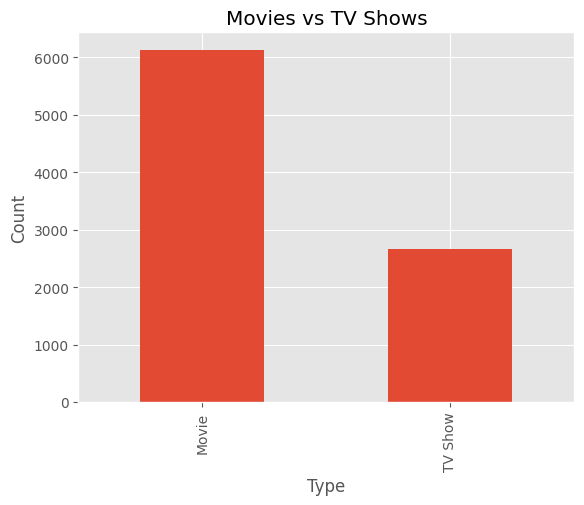

In [ ]:
df['type'].value_counts().plot(kind='bar')

plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

Chart 2: Line Chart

Content Released Per Year

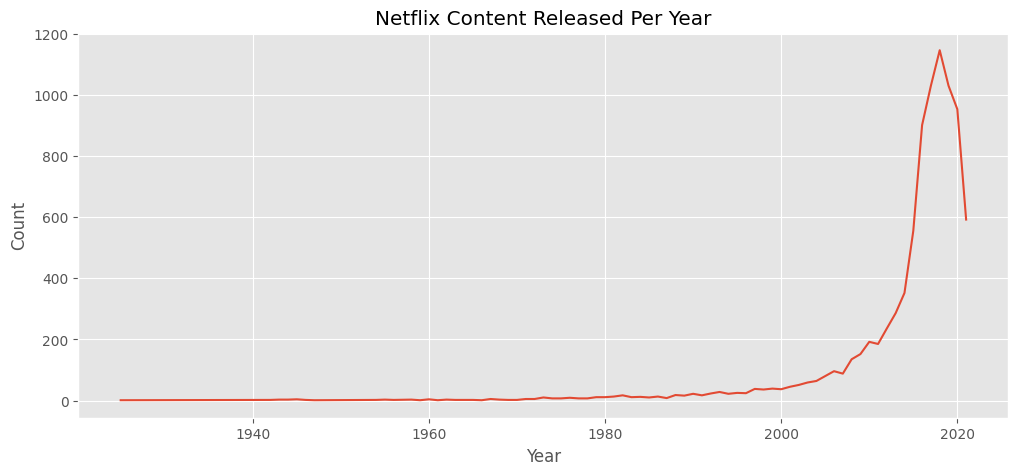

In [ ]:
yearly = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(yearly.index, yearly.values)

plt.title('Netflix Content Released Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

Chart 3: Histogram

Release Year Distribution

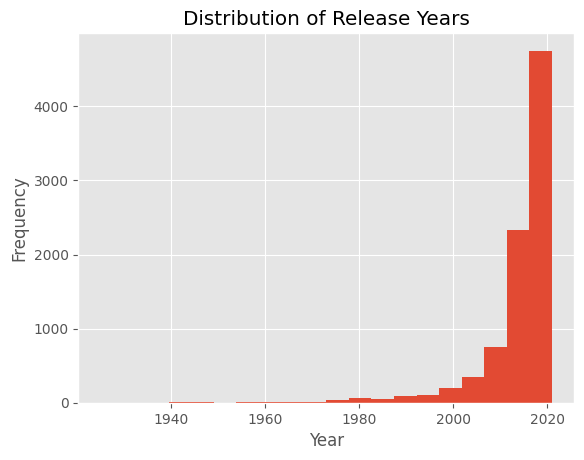

In [ ]:
plt.hist(df['release_year'], bins=20)

plt.title('Distribution of Release Years')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

Chart 4: Pie Chart

Movies vs TV Shows

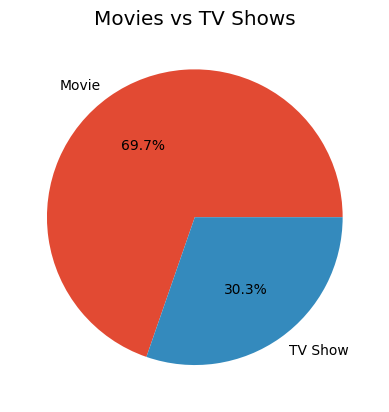

In [ ]:
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Movies vs TV Shows')
plt.ylabel('')
plt.show()

Chart 5: Scatter Plot

Release Year vs Rating Codes

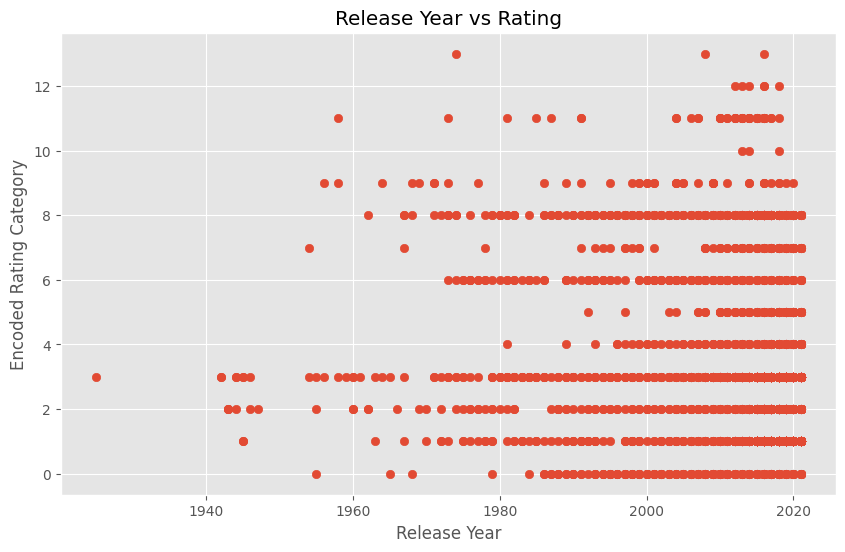

In [ ]:
rating_map = {
    r:i for i,r in enumerate(data['rating'].unique())
}

data['rating_num'] = data['rating'].map(rating_map)

plt.figure(figsize=(10,6))

plt.scatter(
    data['release_year'],
    data['rating_num']
)

plt.title('Release Year vs Rating')
plt.xlabel('Release Year')
plt.ylabel('Encoded Rating Category')

plt.show()

Chart 6: Heatmap

Correlation Heatmap

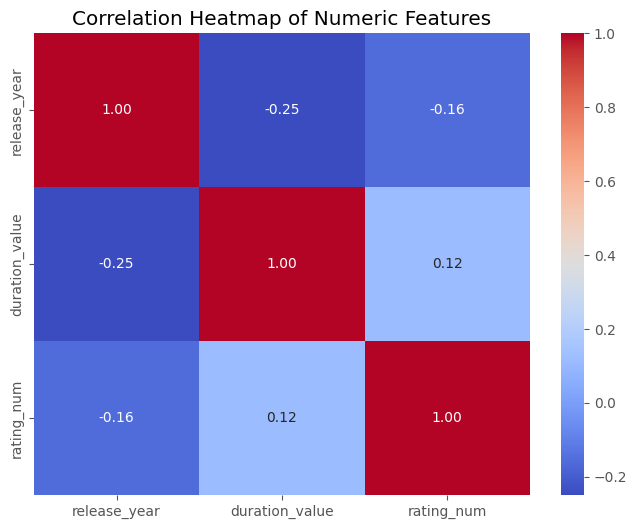

In [ ]:
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# Step 5 – Insights Report

### 1. Netflix Catalog is Dominated by Movies

Based on the Bar Chart and Pie Chart, Movies account for approximately 69.7% of all titles, while TV Shows account for only 30.3%. This indicates that Netflix's content library is primarily focused on movies.

### 2. The United States Produces the Most Netflix Content

The country-wise analysis showed that the United States contributes the highest number of titles on Netflix, followed by India and the United Kingdom. This suggests that North America remains Netflix's largest content source.

### 3. Netflix Experienced Rapid Content Growth After 2015

The yearly additions analysis revealed a dramatic increase in titles after 2015. Content additions peaked around 2019–2020, indicating aggressive expansion of the Netflix catalog during this period.

### 4. Mature Audience Content is the Most Common

The rating analysis showed that TV-MA and TV-14 are the most frequent content ratings for both Movies and TV Shows. This suggests that Netflix focuses heavily on content intended for teenage and adult audiences.

### 5. Drama is the Most Popular Genre on Netflix

Genre analysis revealed that Drama is the most common genre, followed by Comedy and Action & Adventure. This indicates strong audience demand for story-driven entertainment and diverse narrative content.

### 6. Most Netflix Content Was Released in Recent Years

The histogram of release years shows a strong concentration of titles released after 2000, particularly after 2010. This suggests that Netflix primarily offers modern content rather than older productions.

### 7. Weak Relationship Between Release Year and Rating

The heatmap showed a correlation of approximately -0.16 between release year and rating category, indicating a very weak relationship. Content ratings appear largely independent of release year.


## Surprising Finding

One surprising finding from the analysis was that although Netflix is known for streaming content worldwide, nearly **70% of its catalog consists of Movies**, while only about **30% are TV Shows**. Many users associate Netflix with popular TV series, but the data shows that movies actually dominate the platform's content library.

Another interesting observation was that **India is the second-largest content producer on Netflix**, behind only the United States. This highlights the significant contribution of Indian entertainment to Netflix's global catalog.

Additionally, the analysis revealed that **Netflix experienced explosive growth in content additions after 2015**, with the highest number of titles added around 2019–2020. This rapid expansion reflects Netflix's aggressive investment in content during that period.
